# 06 — Executive Summary

Compile all findings into a final narrative with summary plots.
Generate `outputs/FINDINGS.md` from notebook results.

In [1]:
from pathlib import Path
import json
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

OUTPUT_DIR = Path("../outputs")
PLOT_DIR = OUTPUT_DIR / "plots"
METRICS_DIR = OUTPUT_DIR / "metrics"

# Load all metrics
eda = json.load(open(METRICS_DIR / "eda_metrics.json"))
hypothesis = json.load(open(METRICS_DIR / "hypothesis_tests.json"))
ml = json.load(open(METRICS_DIR / "ml_model_metrics.json"))
sim = json.load(open(METRICS_DIR / "simulation_results.json"))

print("All metrics loaded.")

All metrics loaded.


## Executive Summary Plot

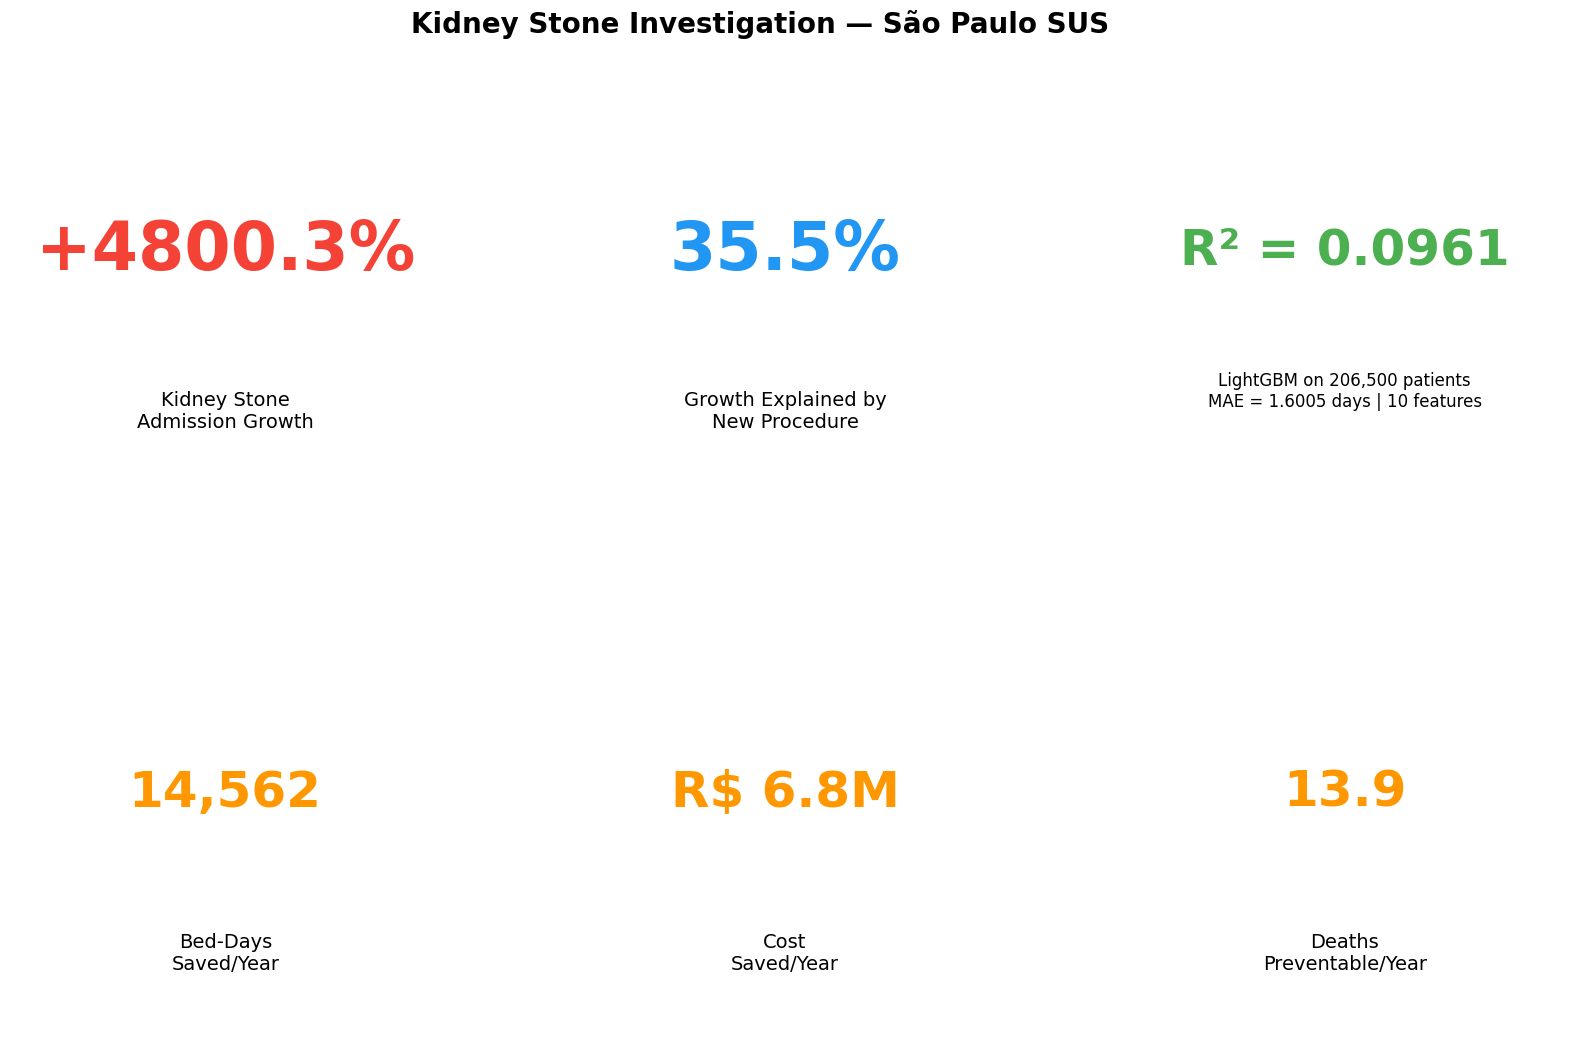

In [2]:
fig = plt.figure(figsize=(20, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.3, wspace=0.3)

# Panel 1: Growth headline
ax1 = fig.add_subplot(gs[0, 0])
ax1.text(0.5, 0.7, f"+{eda['growth_pct']}%", transform=ax1.transAxes,
         fontsize=48, fontweight="bold", ha="center", va="center", color="#F44336")
ax1.text(0.5, 0.3, "Kidney Stone\nAdmission Growth", transform=ax1.transAxes,
         fontsize=14, ha="center", va="center")
ax1.set_xlim(0, 1)
ax1.set_ylim(0, 1)
ax1.axis("off")

# Panel 2: Root cause
ax2 = fig.add_subplot(gs[0, 1])
h1 = hypothesis["H1_procedure_decomposition"]
ax2.text(0.5, 0.7, f"{h1['pct_explained_by_new_proc']}%",
         transform=ax2.transAxes, fontsize=48, fontweight="bold",
         ha="center", va="center", color="#2196F3")
ax2.text(0.5, 0.3, "Growth Explained by\nNew Procedure", transform=ax2.transAxes,
         fontsize=14, ha="center", va="center")
ax2.axis("off")

# Panel 3: ML model
ax3 = fig.add_subplot(gs[0, 2])
ax3.text(0.5, 0.7, f"R² = {ml['r2']}", transform=ax3.transAxes,
         fontsize=36, fontweight="bold", ha="center", va="center", color="#4CAF50")
ax3.text(0.5, 0.35, f"LightGBM on {ml['n_train']+ml['n_test']:,} patients\n"
         f"MAE = {ml['mae']} days | {ml['n_features']} features",
         transform=ax3.transAxes, fontsize=12, ha="center", va="center")
ax3.axis("off")

# Panel 4-6: Simulation impact
combined = sim["combined_impact"]
impact_items = [
    (f"{combined['total_bed_days_saved']:,}", "Bed-Days\nSaved/Year"),
    (f"R$ {combined['cost_saved_brl']/1e6:.1f}M", "Cost\nSaved/Year"),
    (f"{combined['deaths_prevented']}", "Deaths\nPreventable/Year"),
]

for i, (value, label) in enumerate(impact_items):
    ax = fig.add_subplot(gs[1, i])
    ax.text(0.5, 0.65, value, transform=ax.transAxes,
            fontsize=36, fontweight="bold", ha="center", va="center", color="#FF9800")
    ax.text(0.5, 0.25, label, transform=ax.transAxes,
            fontsize=14, ha="center", va="center")
    ax.axis("off")

fig.suptitle("Kidney Stone Investigation — São Paulo SUS", fontsize=20, fontweight="bold", y=0.98)
plt.savefig(PLOT_DIR / "06_executive_summary.png", dpi=150, bbox_inches="tight")
plt.show()

## Generate FINDINGS.md

In [3]:
h2 = hypothesis["H2_access_gap"]

findings = f"""# Kidney Stone Investigation — Findings

## The Headline

Kidney stone (N20) admissions in São Paulo grew **+{eda['growth_pct']}%** from {eda['year_range'][0]} to {eda['year_range'][1]}.
Total admissions: **{eda['total_admissions']:,}**.

## Root Cause: Not an Epidemic

**{h1['pct_explained_by_new_proc']}%** of the growth is explained by adoption of a new surgical procedure
(Transureteroscopic Ureterolithotripsy — code 0409010596), not by increased kidney stone incidence.

## Access Gap

- Migration rate without local access: **{h2['migration_rate_no_access']}%**
- Migration rate with local access: **{h2['migration_rate_with_access']}%**
- Only **{h2['adopter_cities_count']}** cities perform the new procedure

## ML Model: What Drives Length of Stay

- **Model**: LightGBM, {ml['n_train']+ml['n_test']:,} patients, {ml['n_features']} features
- **R² = {ml['r2']}** | MAE = {ml['mae']} days | RMSE = {ml['rmse']} days
- **Baseline MAE**: {ml['baseline_mae']} days (predict mean)
- **Top SHAP drivers**: Emergency admission type, hospital conservative treatment culture, age

## Policy Simulation: Quantified Impact

### Intervention 1: Elective Urology Pathway
Convert 30% of ER admissions to elective at high-ER hospitals.
- Bed-days saved: **{sim['intervention_1_elective']['bed_days_saved']:,}**/year
- Beds freed: **{sim['intervention_1_elective']['beds_freed']}**

### Intervention 2: Protocol Standardization
Reduce conservative treatment rate to ≤20% at high-conservative hospitals.
- Bed-days saved: **{sim['intervention_2_protocol']['bed_days_saved']:,}**/year
- Beds freed: **{sim['intervention_2_protocol']['beds_freed']}**

### Combined (per year)
| Metric | Value |
|---|---|
| Bed-days saved | {combined['total_bed_days_saved']:,} |
| Beds freed | {combined['total_beds_freed']} |
| Cost saved | R$ {combined['cost_saved_brl']/1e6:.1f}M |
| Deaths preventable | {combined['deaths_prevented']} |
| Long stays eliminated | {combined['long_stays_eliminated']} |

## Methodology

- Data: SIH AIH Reduzida, São Paulo, {eda['year_range'][0]}-{eda['year_range'][1]}
- Temporal split: train ≤2021, test ≥2022
- Model: LightGBM with SHAP explainability
- Simulation: Counterfactual predictions using trained model
- See `EXPERIMENT.md` for pre-registered hypotheses and study design
"""

with open(OUTPUT_DIR / "FINDINGS.md", "w") as f:
    f.write(findings)

print("FINDINGS.md generated at outputs/FINDINGS.md")
print("Investigation complete.")

FINDINGS.md generated at outputs/FINDINGS.md
Investigation complete.
